<a href="https://colab.research.google.com/github/Amenbiz/House-Pricing/blob/main/notebooks/house_price_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
# CELL 1 — Imports Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 150, "figure.figsize": (10, 6)})


In [2]:
# CELL 2 — Load the Dataset

df = pd.read_csv("housing.csv")

print(df.shape)
df.head(5)

(20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [36]:
# CELL 3 — Dataset Inspection

df.info()

print("\n Descriptive Statistics")
df.describe().round(2)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   20640 non-null  float64
 1   latitude                    20640 non-null  float64
 2   housing_median_age          20640 non-null  float64
 3   total_rooms                 20640 non-null  float64
 4   total_bedrooms              20640 non-null  float64
 5   population                  20640 non-null  float64
 6   households                  20640 non-null  float64
 7   median_income               20640 non-null  float64
 8   median_house_value          20640 non-null  float64
 9   is_capped                   20640 non-null  bool   
 10  rooms_per_household         20640 non-null  float64
 11  bedrooms_per_room           20640 non-null  float64
 12  population_per_household    20640 non-null  float64
 13  log_total_rooms             206

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household,log_total_rooms,log_total_bedrooms,log_population,log_households
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,-119.57,35.63,0.00,2635.76,536.84,1425.48,499.54,0.00,206855.82,0.00,0.00,0.00,-0.00,0.00,-0.00,0.00
std,2.00,2.14,1.00,2181.62,419.39,1132.46,382.33,1.00,115395.62,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-124.35,32.54,-2.20,2.00,1.00,3.00,1.00,-1.77,14999.00,-1.85,-2.71,-0.23,-8.71,-7.42,-7.66,-7.28
25%,-121.80,33.93,-0.85,1447.75,297.00,787.00,280.00,-0.69,119600.00,-0.40,-0.59,-0.06,-0.47,-0.49,-0.48,-0.48
50%,-118.49,34.26,0.03,2127.00,435.00,1166.00,409.00,-0.18,179700.00,-0.08,-0.16,-0.02,0.04,0.03,0.05,0.04
75%,-118.01,37.71,0.66,3148.00,643.25,1725.00,605.00,0.46,264725.00,0.25,0.40,0.02,0.57,0.57,0.58,0.58
max,-114.31,41.95,1.86,39320.00,6445.00,35682.00,6082.00,5.86,500001.00,55.16,40.02,119.42,3.93,3.76,4.70,3.75


In [37]:
# Cell 4 - Spotting Missing Values

missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing (%)": missing_pct
})

missing_summary = missing_summary[missing_summary["Missing Count"] > 0]
print(missing_summary)

plt.tight_layout()
plt.show()

Empty DataFrame
Columns: [Missing Count, Missing (%)]
Index: []


<Figure size 1500x900 with 0 Axes>

In [41]:
# CELL 5 — Fixing Missing Values (Imputation)

median_bedrooms = df["total_bedrooms"].median()

df["total_bedrooms"] = df["total_bedrooms"].fillna(median_bedrooms)

print(df.isnull().sum().sum())
print("All missing values resolved.")


0
All missing values resolved.


In [42]:
# CELL 6 — Checking for Duplicate Rows

duplicate_count = df.duplicated().sum()
print(f"Duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"Removed {duplicate_count} duplicate rows.")
    print(f"New dataset shape: {df.shape}")
else:
    print("No duplicates found.")

Duplicate rows found: 0
No duplicates found.


In [44]:
# CELL 7 — Identifying Capped Target Values

capped_count = (df["median_house_value"] == 500001).sum()
capped_pct = (capped_count / len(df) * 100).round(2)

print(f"Rows with capped value ($500,001): {capped_count} ({capped_pct}% of dataset)")

# Add a flag column, useful for analysis.

df["is_capped"] = df["median_house_value"] == 500001

Rows with capped value ($500,001): 965 (4.68% of dataset)


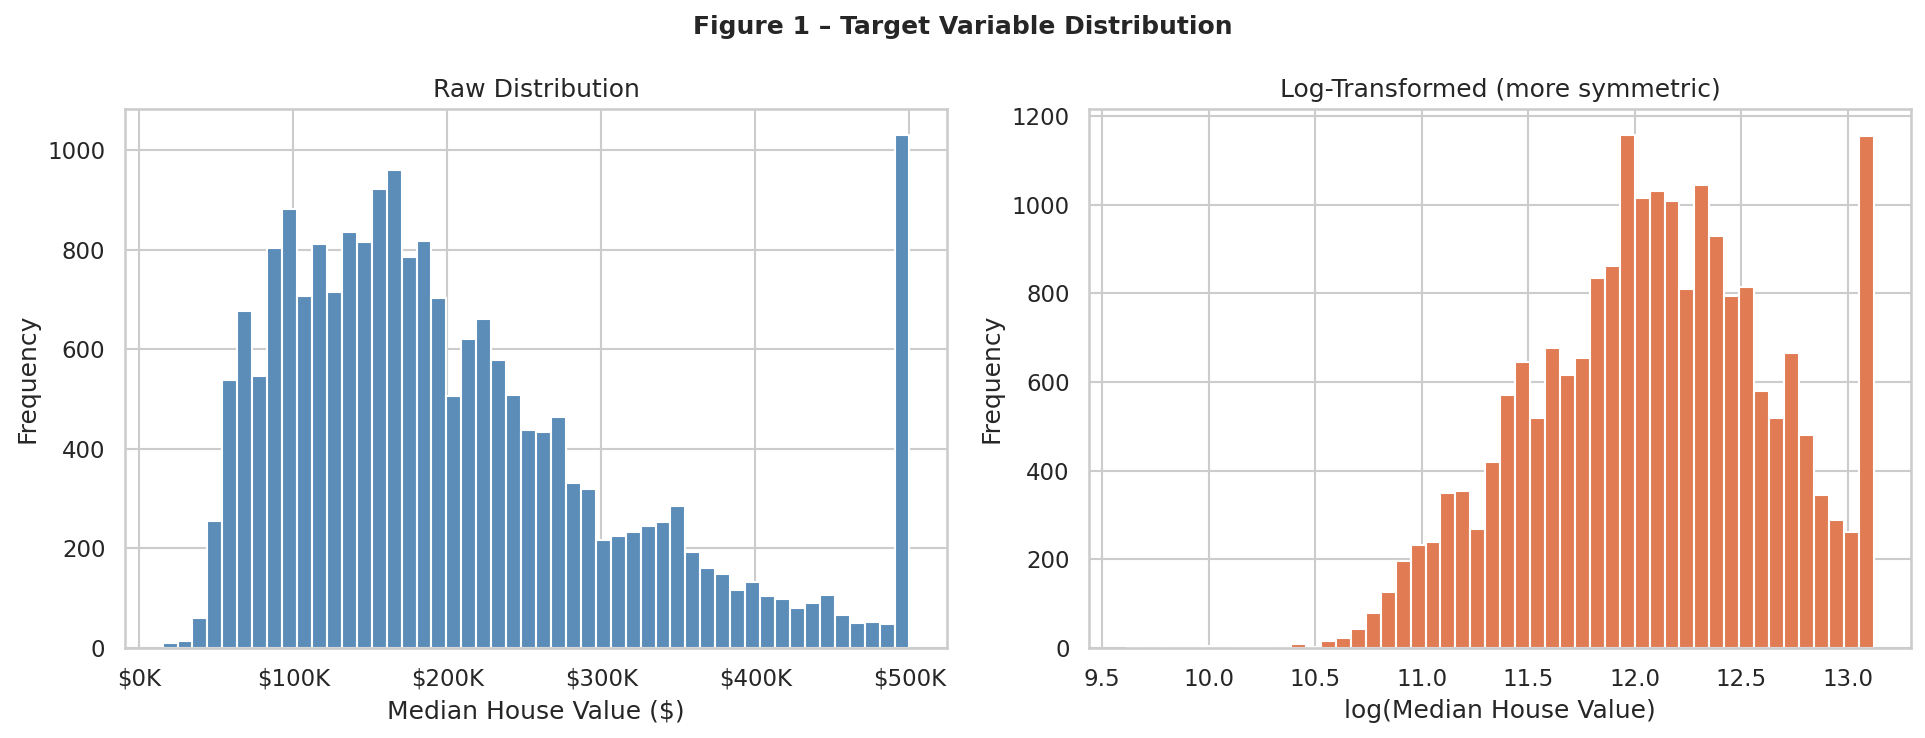

In [45]:
# CELL 8 — Target Variable Distribution

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

#  Left: raw distribution

axes[0].hist(df["median_house_value"], bins=50, color="#5B8DB8", edgecolor="white")
axes[0].set_xlabel("Median House Value ($)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Raw Distribution")
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K")
)

#  Right: log-transformed distribution

axes[1].hist(np.log1p(df["median_house_value"]), bins=50, color="#E07B54", edgecolor="white")
axes[1].set_xlabel("log(Median House Value)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Log-Transformed (more symmetric)")

plt.suptitle("Figure 1 – Target Variable Distribution", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_target_distribution.png")
plt.show()

In [48]:
# BOXPLOTS — Spread & Outlier Detection for Each Feature

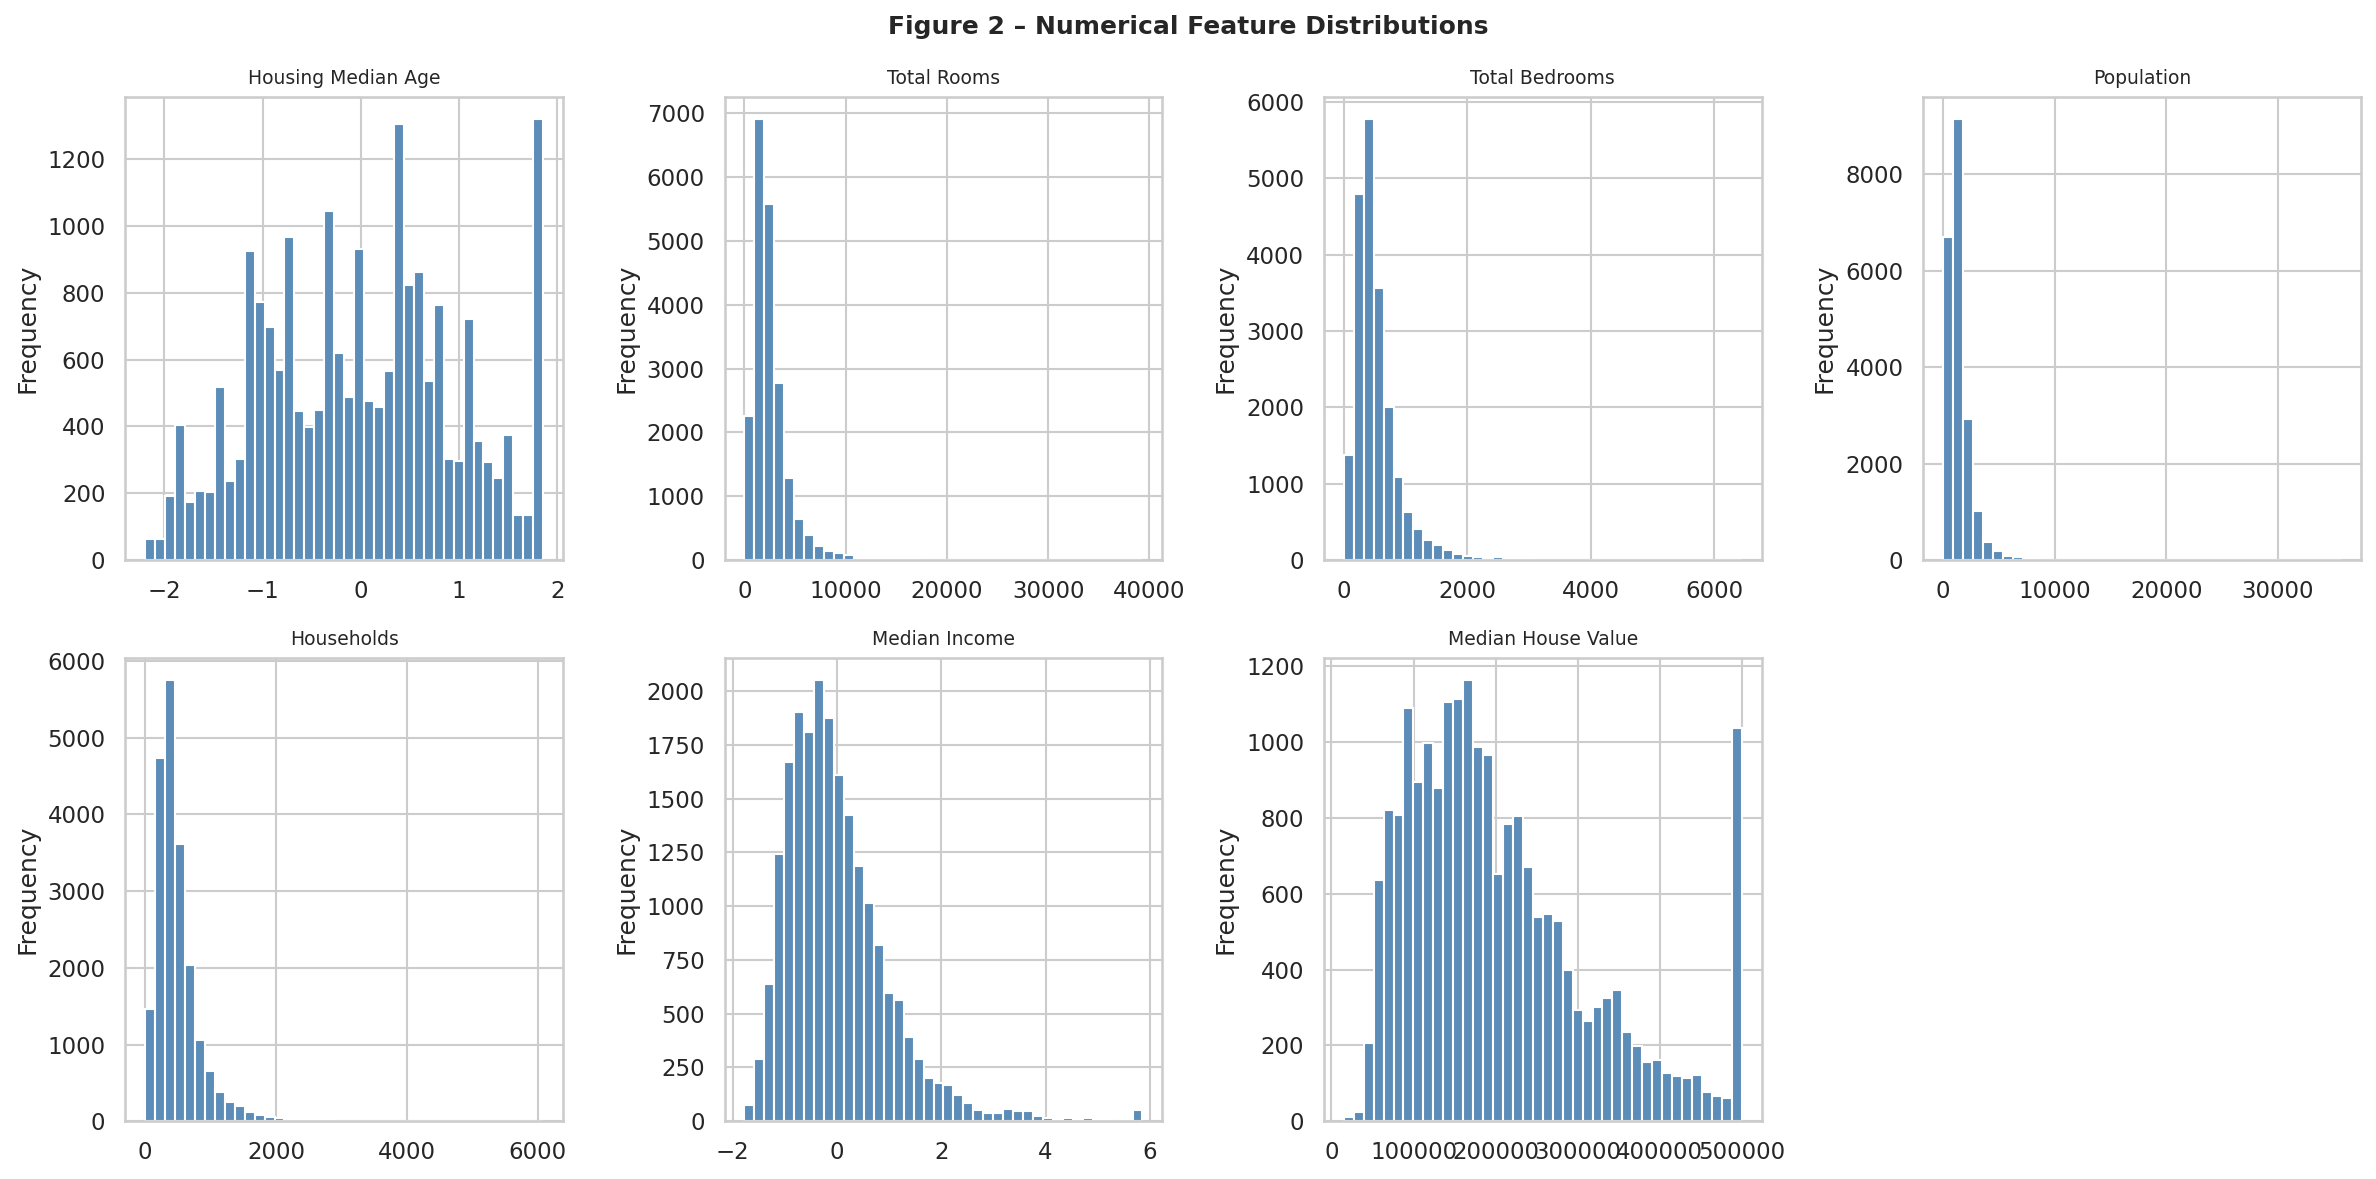

Skewness of Numerical Features
(Values > 1 are notably skewed; > 2 are heavily skewed)

population            4.94
total_rooms           4.15
total_bedrooms        3.48
households            3.41
median_income         1.65
median_house_value    0.98
housing_median_age    0.06
dtype: float64


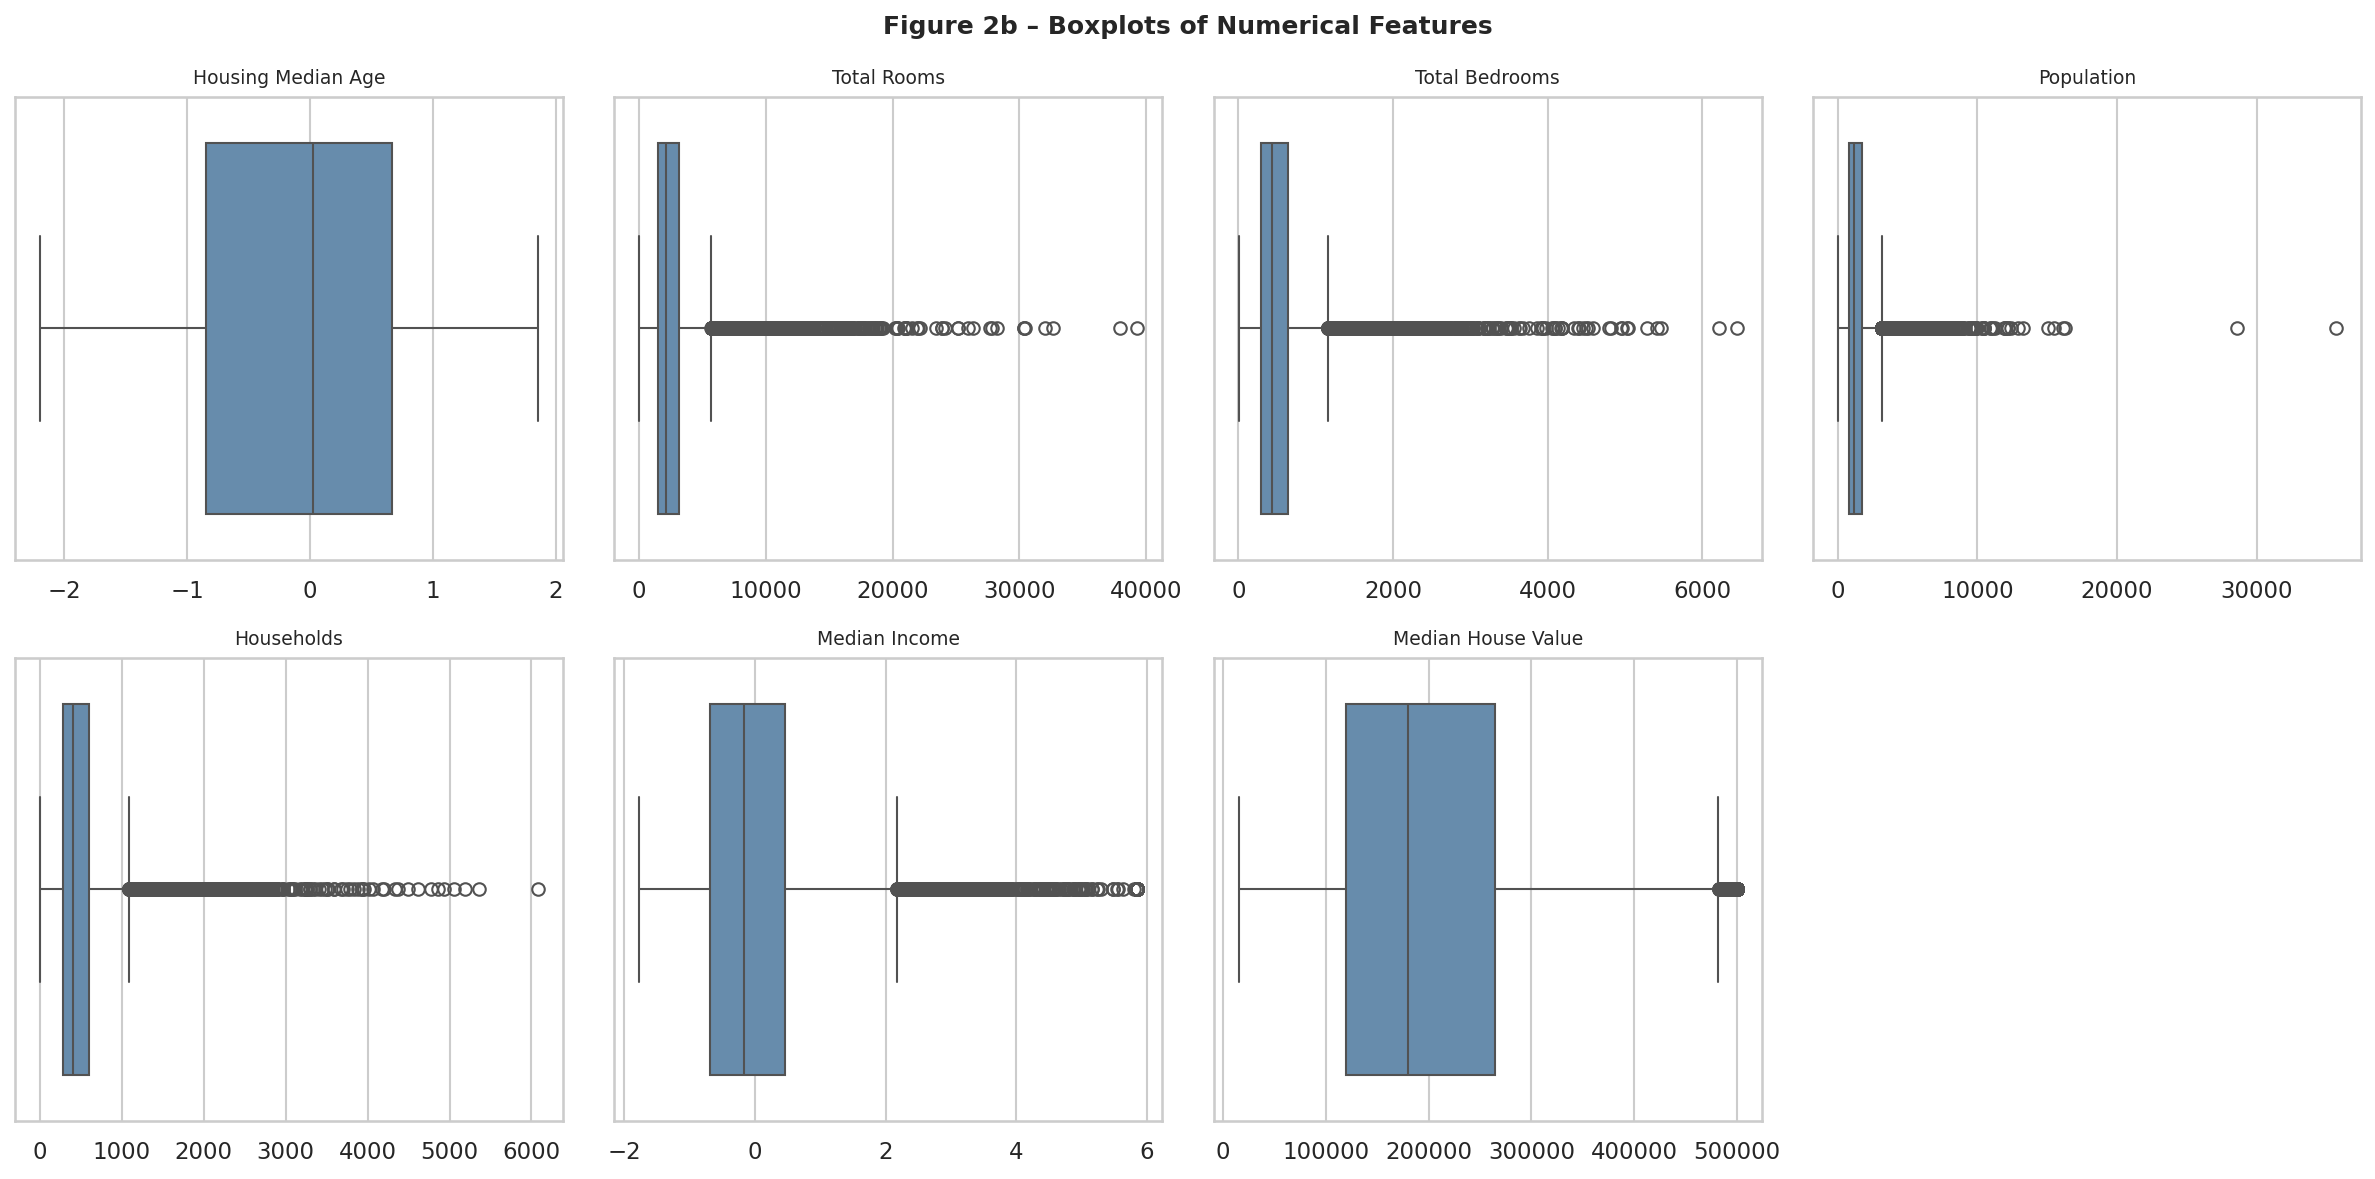

Key observations:
- housing_median_age : well spread, no major outliers
- total_rooms        : heavy right skew, many outliers
- population         : heavy right skew, many outliers
- median_income      : mild skew, some high-end outliers
- median_house_value : outliers visible at high end ($500,001 cap)


In [49]:
# CELL 9 — Feature Distributions, Skewness & Outlier Detection

num_cols = [
    "housing_median_age", "total_rooms", "total_bedrooms",
    "population", "households", "median_income", "median_house_value"
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40, color="#5B8DB8", edgecolor="white")
    axes[i].set_title(col.replace("_", " ").title(), fontsize=9)
    axes[i].set_ylabel("Frequency")

axes[-1].set_visible(False)

plt.suptitle("Figure 2 – Numerical Feature Distributions", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_feature_distributions.png")
plt.show()

# Print skewness values
print("Skewness of Numerical Features")
print("(Values > 1 are notably skewed; > 2 are heavily skewed)\n")
skewness = df[num_cols].skew().round(2).sort_values(ascending=False)
print(skewness)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i], color="#5B8DB8")
    axes[i].set_title(col.replace("_", " ").title(), fontsize=9)
    axes[i].set_xlabel("")

axes[-1].set_visible(False)

plt.suptitle("Figure 2b – Boxplots of Numerical Features",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_boxplots_features.png")
plt.show()

print("Key observations:")
print("- housing_median_age : well spread, no major outliers")
print("- total_rooms        : heavy right skew, many outliers")
print("- population         : heavy right skew, many outliers")
print("- median_income      : mild skew, some high-end outliers")
print("- median_house_value : outliers visible at high end ($500,001 cap)")

In [10]:
# Categorical Feature

/usr/local/lib/python3.12/dist-packages/dateutil/parser/_parser.py:1207: UnknownTimezoneWarning: tzname OCEAN identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "
/tmp/ipykernel_1870/166297420.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_plot, x="ocean_proximity", order=order,
/usr/local/lib/python3.12/dist-packages/dateutil/parser/_parser.py:1207: UnknownTimezoneWarning: tzname OCEAN identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "
/tmp/ipykernel_1870/166297420.py:3

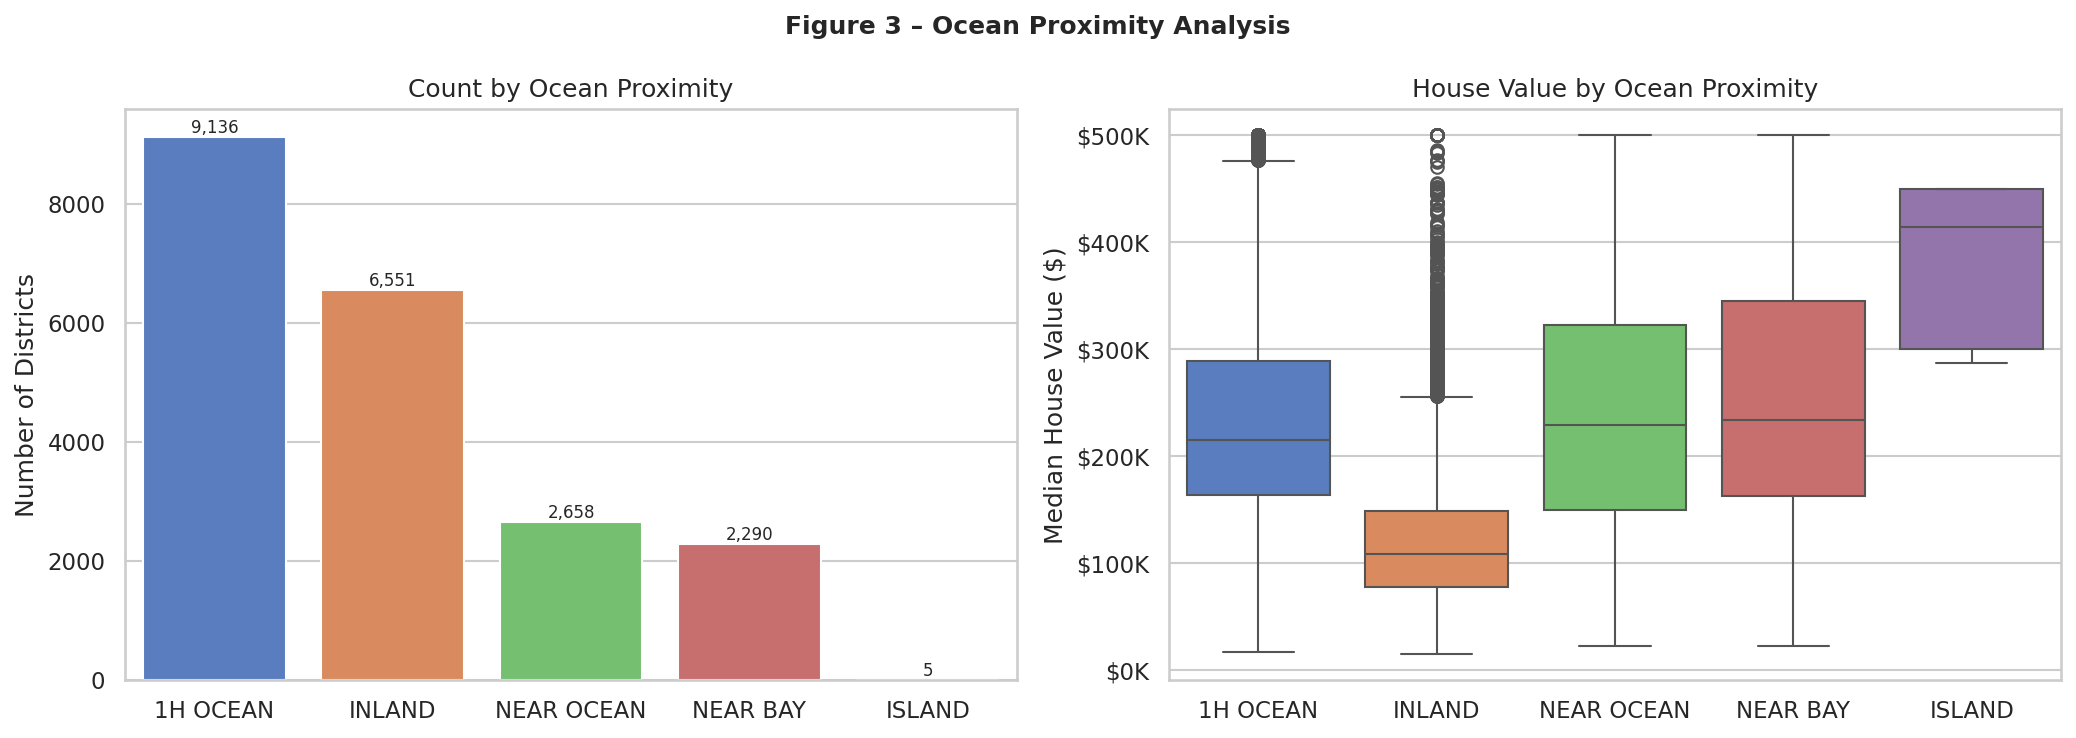

Median House Value by Ocean Proximity
ocean_proximity
ISLAND        $414,700
NEAR BAY      $233,800
NEAR OCEAN    $229,450
1H OCEAN      $214,850
INLAND        $108,500
Name: median_house_value, dtype: object


In [56]:
# CELL 10 — Ocean Proximity Analysis

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if 'ocean_proximity' not in df.columns:
    df_plot = df.copy()
    df_plot['ocean_proximity'] = '1H OCEAN' # Default category (since drop_first=True was used)
    if 'ocean_proximity_INLAND' in df_plot.columns:
        df_plot.loc[df_plot['ocean_proximity_INLAND'] == 1, 'ocean_proximity'] = 'INLAND'
    if 'ocean_proximity_ISLAND' in df_plot.columns:
        df_plot.loc[df_plot['ocean_proximity_ISLAND'] == 1, 'ocean_proximity'] = 'ISLAND'
    if 'ocean_proximity_NEAR BAY' in df_plot.columns:
        df_plot.loc[df_plot['ocean_proximity_NEAR BAY'] == 1, 'ocean_proximity'] = 'NEAR BAY'
    if 'ocean_proximity_NEAR OCEAN' in df_plot.columns:
        df_plot.loc[df_plot['ocean_proximity_NEAR OCEAN'] == 1, 'ocean_proximity'] = 'NEAR OCEAN'
else:
    df_plot = df

# Ordered by frequency so the most common categories appear first
order = df_plot["ocean_proximity"].value_counts().index

#  Left: Count of districts per category
sns.countplot(data=df_plot, x="ocean_proximity", order=order,
              palette="muted", ax=axes[0])
axes[0].set_title("Count by Ocean Proximity")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of Districts")

for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=8)

#  Right: Median house value by category

sns.boxplot(data=df_plot, x="ocean_proximity", y="median_house_value",
            order=order, palette="muted", ax=axes[1])
axes[1].set_title("House Value by Ocean Proximity")
axes[1].set_xlabel("")
axes[1].set_ylabel("Median House Value ($)")
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K")
)

plt.suptitle("Figure 3 – Ocean Proximity Analysis", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_ocean_proximity.png")
plt.show()

# Print median house value per category for the paper

print("Median House Value by Ocean Proximity")
print(df_plot.groupby("ocean_proximity")["median_house_value"]
      .median().sort_values(ascending=False).apply(lambda x: f"${x:,.0f}"))

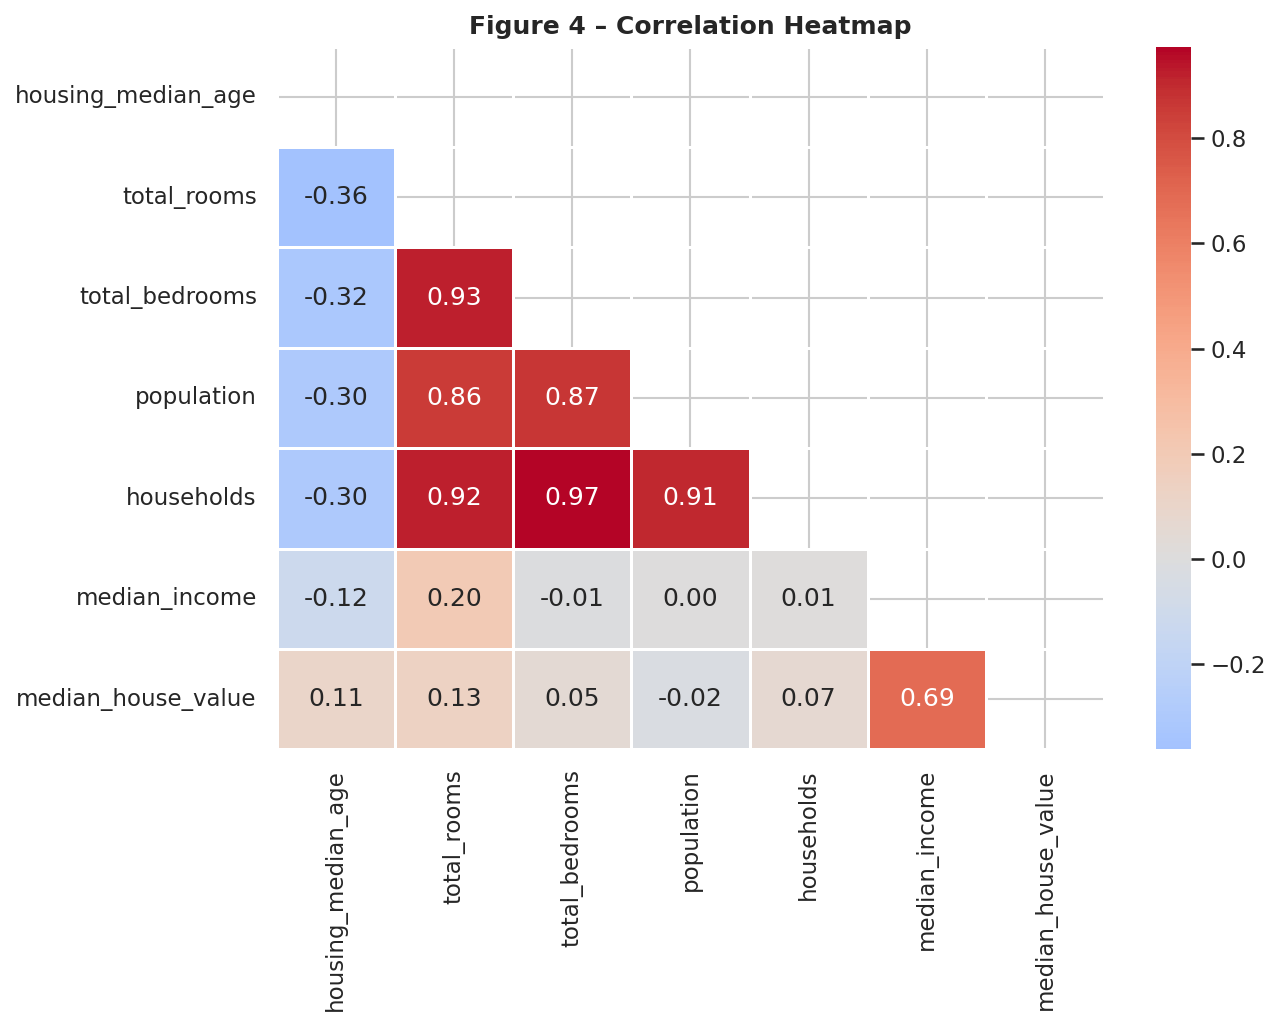

Feature Correlations with median_house_value
median_income         0.688
total_rooms           0.134
housing_median_age    0.106
households            0.066
total_bedrooms        0.049
population           -0.025
Name: median_house_value, dtype: float64


In [57]:
# CELL 11 — Correlation Heatmap

num_cols = [
    "housing_median_age", "total_rooms", "total_bedrooms",
    "population", "households", "median_income", "median_house_value"
]

corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",  # red = positive, blue = negative
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Figure 4 – Correlation Heatmap", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_correlation_heatmap.png")
plt.show()

# Print correlations with the target variable, sorted strongest to weakest
print("Feature Correlations with median_house_value")
target_corr = corr_matrix["median_house_value"].drop("median_house_value")
print(target_corr.sort_values(ascending=False).round(3))

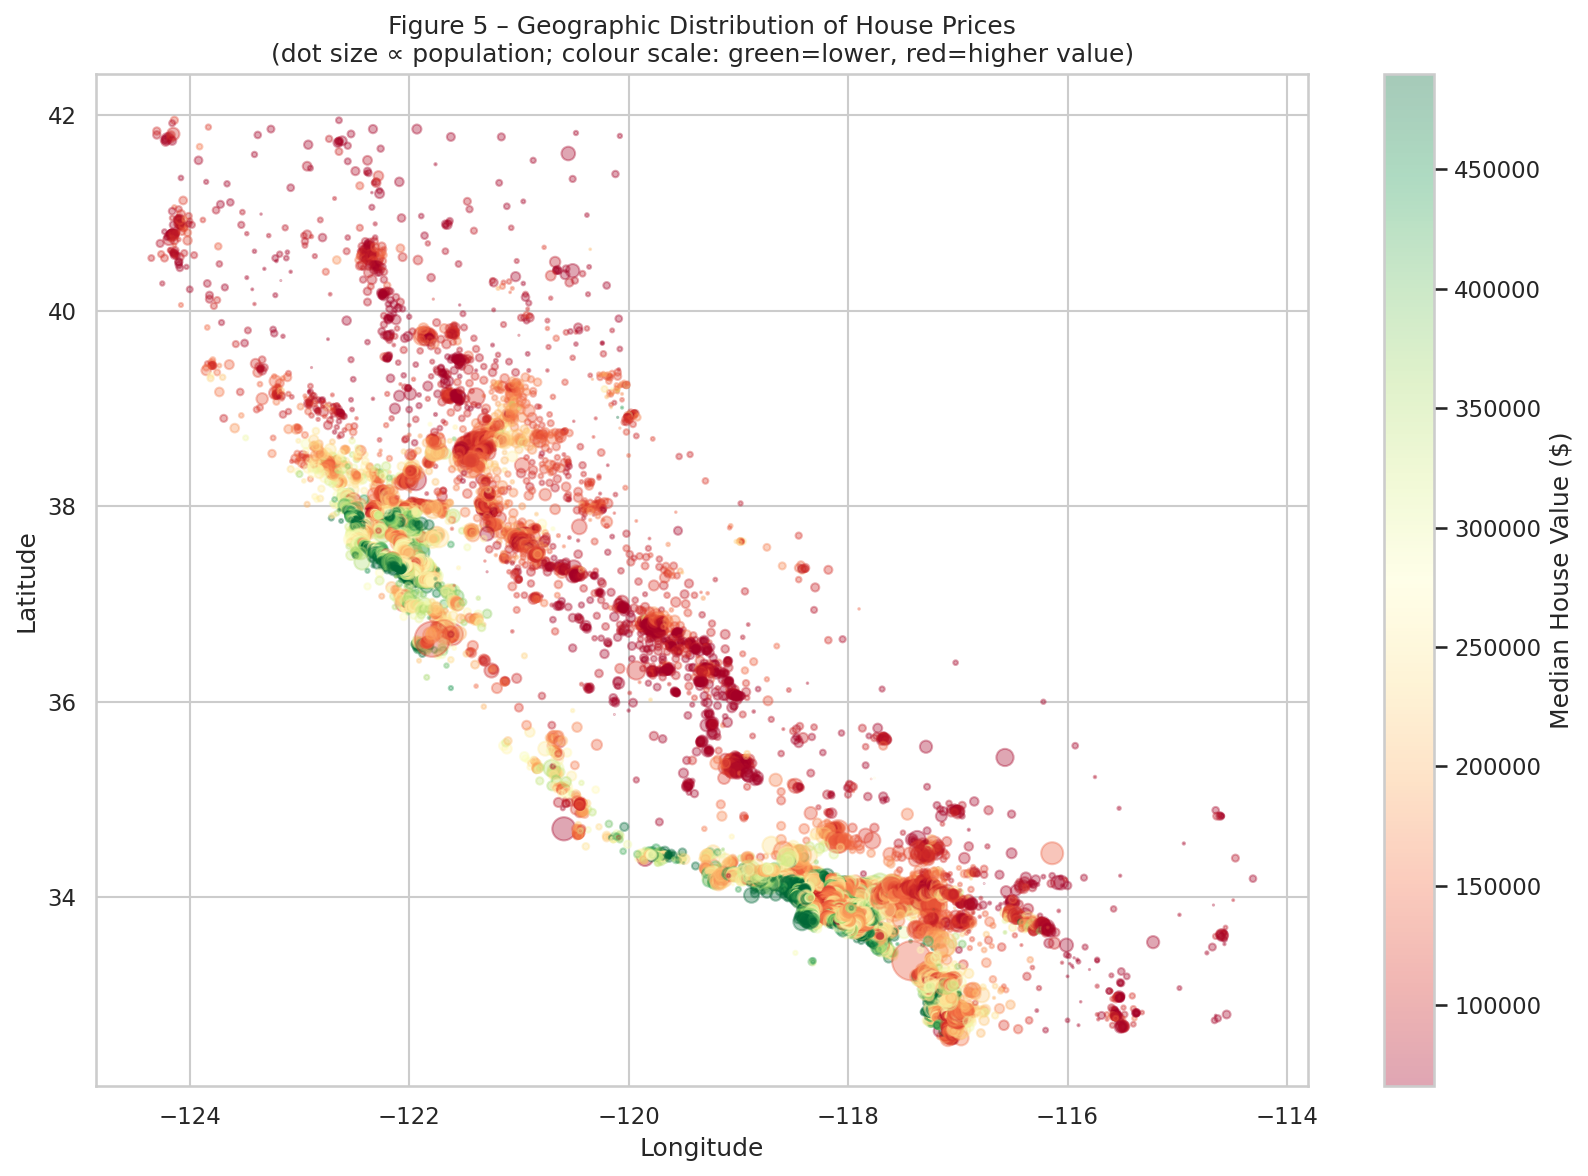

In [13]:
# CELL 12 — Geographic Distribution of House Prices

fig, ax = plt.subplots(figsize=(11, 8))

scatter = ax.scatter(
    df["longitude"],
    df["latitude"],
    c=df["median_house_value"],
    cmap="RdYlGn",
    alpha=0.35,
    s=df["population"] / 100,
    vmin=df["median_house_value"].quantile(0.05),
    vmax=df["median_house_value"].quantile(0.95)
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Median House Value ($)")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(
    "Figure 5 – Geographic Distribution of House Prices\n"
    "(dot size ∝ population; colour scale: green=lower, red=higher value)"
)
plt.tight_layout()
plt.savefig("fig_geographic_distribution.png")
plt.show()


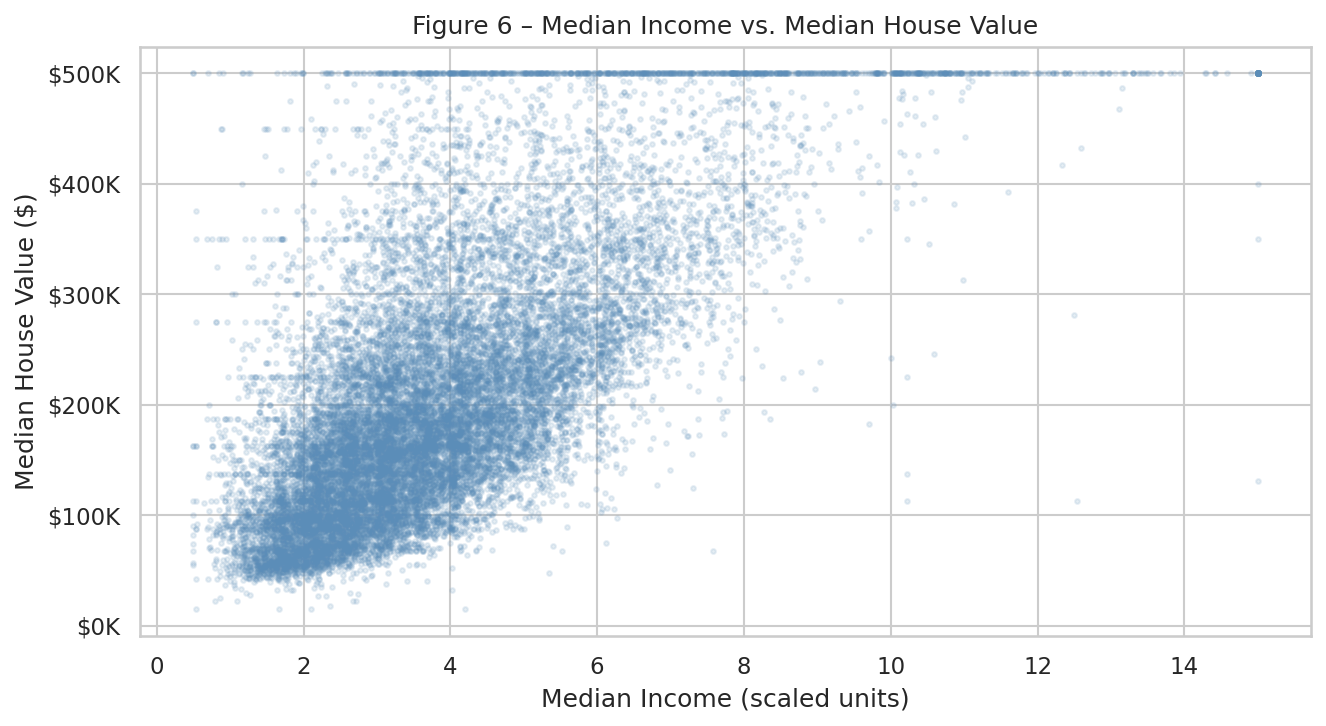

Pearson r = 0.688
p-value   = 0.00e+00

Statistically significant positive correlation (p < 0.05).
As median income increases, median house value increases.


In [14]:
# CELL 13 — Median Income vs. Median House Value

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df["median_income"], df["median_house_value"],
           alpha=0.15, s=5, color="#5B8DB8")
ax.set_xlabel("Median Income (scaled units)")
ax.set_ylabel("Median House Value ($)")
ax.set_title("Figure 6 – Median Income vs. Median House Value")
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K")
)
plt.tight_layout()
plt.savefig("fig_income_vs_value.png")
plt.show()

# Pearson Correlation Test

r, p = stats.pearsonr(df["median_income"], df["median_house_value"])
print(f"Pearson r = {r:.3f}")
print(f"p-value   = {p:.2e}")
print()
if p < 0.05:
    print("Statistically significant positive correlation (p < 0.05).")
    print("As median income increases, median house value increases.")

In [60]:
# Summary of Data Cleaning and Exploratory Data Analysis (EDA)

In [61]:
# CELL 14 — Summary & Saving Cleaned Dataset

r, p = stats.pearsonr(df["median_income"], df["median_house_value"])


print("Data Cleaning & EDA")

print(f"  Total records:              {len(df):,}")

print(f"  Total features:             {df.shape[1] - 1} (excl. target & cap flag)")
print(f"  Missing values fixed:       207 (total_bedrooms — median imputation)")
print(f"  Duplicate rows removed:     0")
print(f"  Capped target values:       965 rows (4.67%) — flagged, kept")
print(f"  Skewed features identified: total_rooms, total_bedrooms, population")
print(f"  Strongest predictor:        median_income (Pearson r = {r:.3f})")
print(f"  Geographic pattern found:   Coastal areas command premium prices")








Data Cleaning & EDA
  Total records:              20,640
  Total features:             20 (excl. target & cap flag)
  Missing values fixed:       207 (total_bedrooms — median imputation)
  Duplicate rows removed:     0
  Capped target values:       965 rows (4.67%) — flagged, kept
  Skewed features identified: total_rooms, total_bedrooms, population
  Strongest predictor:        median_income (Pearson r = 0.688)
  Geographic pattern found:   Coastal areas command premium prices


In [ ]:
# New Features and Description

In [73]:
# CELL 15 — Creating New Features

# New Feature 1 — Rooms per Household
df['rooms_per_household'] = df['total_rooms'] / df['households']

# New Feature 2 — Bedrooms per Room
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']

# New Feature 3 — Population per Household
df['population_per_household'] = df['population'] / df['households']

print("df.shape")
print("Shape after new features:", df.shape)
print("\n")
print(df[['rooms_per_household',
          'bedrooms_per_room',
          'population_per_household']].describe().round(2))

df.shape
Shape after new features: (20640, 21)


       rooms_per_household  bedrooms_per_room  population_per_household
count             20640.00           20640.00                  20640.00
mean                  5.43               0.21                      3.07
std                   2.47               0.07                     10.39
min                   0.85               0.04                      0.69
25%                   4.44               0.18                      2.43
50%                   5.23               0.20                      2.82
75%                   6.05               0.24                      3.28
max                 141.91               2.82                   1243.33


In [79]:
# Log Transformation and Comparison between np.log1p and np.square root


Shape is now: (20640, 21)


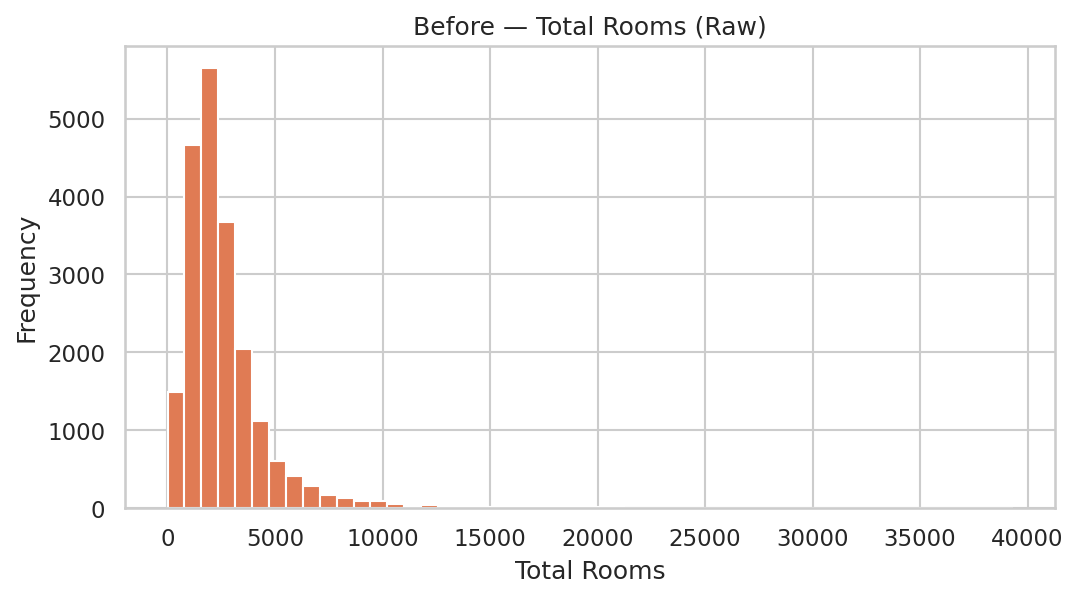

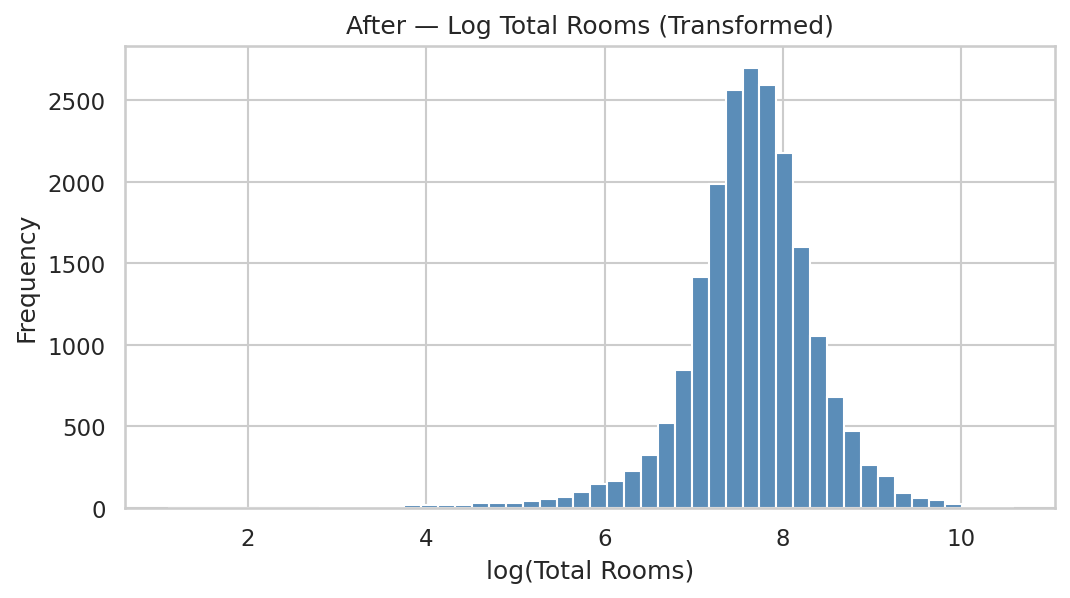


Skewness Before and After Log Transformation
total_rooms      — Before: 4.15       After: -1.08
total_bedrooms   — Before: 3.48       After: -1.00
population       — Before: 4.94       After: -1.04
households       — Before: 3.41       After: -1.05


In [81]:
# CELL 16 — Log Transformation of Skewed Features

# Four features are heavly right skew:
# total_rooms, total_bedrooms, population, households.

df['log_total_rooms']      = np.log1p(df['total_rooms'])
df['log_total_bedrooms']   = np.log1p(df['total_bedrooms'])
df['log_population']       = np.log1p(df['population'])
df['log_households']       = np.log1p(df['households'])

print()
print("Shape is now:", df.shape)

# Before and After Comparison for total_rooms
# We visualise one feature before and after to show the effect

plt.figure(figsize=(8, 4))
plt.hist(df['total_rooms'], bins=50, color="#E07B54", edgecolor="white")
plt.title('Before — Total Rooms (Raw)')
plt.xlabel('Total Rooms')
plt.ylabel('Frequency')
plt.savefig('fig_before_log.png')
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(df['log_total_rooms'], bins=50, color="#5B8DB8", edgecolor="white")
plt.title('After — Log Total Rooms (Transformed)')
plt.xlabel('log(Total Rooms)')
plt.ylabel('Frequency')
plt.savefig('fig_after_log.png')
plt.show()

# Print skewness before and after for all 4 features
print("\nSkewness Before and After Log Transformation")
print(f"total_rooms      — Before: {df['total_rooms'].skew():.2f}       After: {df['log_total_rooms'].skew():.2f}")
print(f"total_bedrooms   — Before: {df['total_bedrooms'].skew():.2f}       After: {df['log_total_bedrooms'].skew():.2f}")
print(f"population       — Before: {df['population'].skew():.2f}       After: {df['log_population'].skew():.2f}")
print(f"households       — Before: {df['households'].skew():.2f}       After: {df['log_households'].skew():.2f}")

In [75]:
# Encoding ocean_proximity

In [76]:
# CELL 17 —  (One-Hot Encoding)

# Models can only work with numbers and not text.
# One-hot encoding helps to converts ocean_proximity into 0/1 columns,one for each category.

if 'ocean_proximity' in df.columns:
    df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)
    print("Encoding applied successfully!")
else:
    print("Already encoded — skipping!")

ocean_cols = [col for col in df.columns if 'ocean' in col]
print("\n Count of 1s in each encoded column ")
print(df[ocean_cols].sum())

Already encoded — skipping!

 Count of 1s in each encoded column 
ocean_proximity_INLAND        6551
ocean_proximity_ISLAND           5
ocean_proximity_NEAR BAY      2290
ocean_proximity_NEAR OCEAN    2658
dtype: int64


In [82]:
# Feature Scaling

In [87]:
# CELL 18 — Feature Scaling

#   Features have very different value ranges.
#   median_income → 0 to 15
#   total_rooms   → 0 to 39,000
#   because we want our predictions in real dollar amounts we also do not scale our target variable
#   "median_house_value"

from sklearn.preprocessing import StandardScaler

# These are the features we want to scale
features_to_scale = [
    'housing_median_age',
    'median_income',
    'rooms_per_household',
    'bedrooms_per_room',
    'population_per_household',
    'log_total_rooms',
    'log_total_bedrooms',
    'log_population',
    'log_households'
]

# Create scaler
scaler = StandardScaler()

# Applying scaling — fit_transform learns the mean and std
# from our data then scales it in one step

df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print("\nSample of scaled features (first 3 rows):")
print(df[features_to_scale].head(3).round(3))

print("\nMean of scaled features")
print(df[features_to_scale].mean().round(3))

print("\nStd of scaled features")
print(df[features_to_scale].std().round(3))


Sample of scaled features (first 3 rows):
   housing_median_age  median_income  rooms_per_household  bedrooms_per_room  \
0               0.982          2.345                0.629             -1.030   
1              -0.607          2.332                0.327             -0.889   
2               1.856          1.783                1.156             -1.292   

   population_per_household  log_total_rooms  log_total_bedrooms  \
0                    -0.050           -1.131              -1.642   
1                    -0.093            1.651               1.320   
2                    -0.026           -0.450              -1.110   

   log_population  log_households  
0          -1.695          -1.569  
1           1.030           1.449  
2          -1.110          -1.105  

Mean of scaled features
housing_median_age         -0.0
median_income              -0.0
rooms_per_household         0.0
bedrooms_per_room           0.0
population_per_household    0.0
log_total_rooms            -0.0
lo

In [88]:
# Data Preparation, Training and Testing

In [90]:
# CELL 19 — Preparing Data & Train/Test Split

#   We separate our data into:
#   X — input features (what the model uses to predict)
#   y — target variable (what we want to predict)
#   Then we split both into training (80%) and test (20%) sets.

from sklearn.model_selection import train_test_split

X = df.drop(columns=['median_house_value', 'is_capped'])
y = df['median_house_value']

print(" Data Preparation ")
print("X shape (features):", X.shape)
print("y shape (target):", y.shape)
print("\nFeatures used for prediction:")
print(X.columns.tolist())

# Step 2 — Split into training and test sets
# random_state=42 ensures we get the same split every time

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\n Split Summary ")
print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")
print(f"Total:        {X_train.shape[0] + X_test.shape[0]} rows")


 Data Preparation 
X shape (features): (20640, 19)
y shape (target): (20640,)

Features used for prediction:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'log_total_rooms', 'log_total_bedrooms', 'log_population', 'log_households', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']

 Split Summary 
Training set: 16512 rows
Test set:     4128 rows
Total:        20640 rows


In [92]:
# Linear Regression Measuring Performance with RMSE and R²

Linear Regression model trained!

 Linear Regression Results 
RMSE: $72,237
R²:   0.602


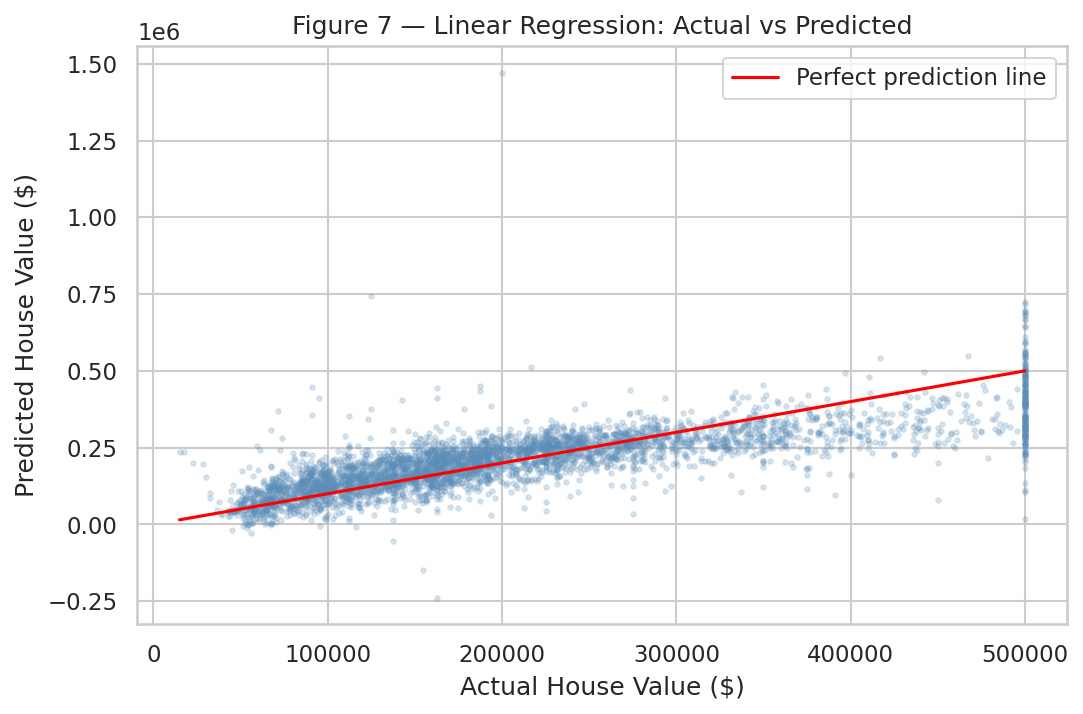

In [91]:
# CELL 20 — Linear Regression

# Linear Regression is our baseline model.
# It finds the best straight line relationship between our 19 features and median_house_value.

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Step 1 — Create model
lr_model = LinearRegression()

# Step 2 — Train the model on the training set
lr_model.fit(X_train, y_train)
print("Linear Regression model trained!")

# Step 3 — Make predictions on the test set
lr_predictions = lr_model.predict(X_test)

# Step 4 — Measure performance
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)

print("\n Linear Regression Results ")
print(f"RMSE: ${lr_rmse:,.0f}")
print(f"R²:   {lr_r2:.3f}")

# Step 5 — Visualise predictions vs actual values
plt.figure(figsize=(8, 5))
plt.scatter(y_test, lr_predictions, alpha=0.2, s=5, color="#5B8DB8")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=1.5, label='Perfect prediction line')
plt.xlabel("Actual House Value ($)")
plt.ylabel("Predicted House Value ($)")
plt.title("Figure 7 — Linear Regression: Actual vs Predicted")
plt.legend()
plt.savefig("fig_lr_predictions.png")
plt.show()





In [25]:
# Decision Tree "Considering Max depth = 10"

 Decision Tree model trained!

 Decision Tree Results 
RMSE: $64,175
R²:   0.686


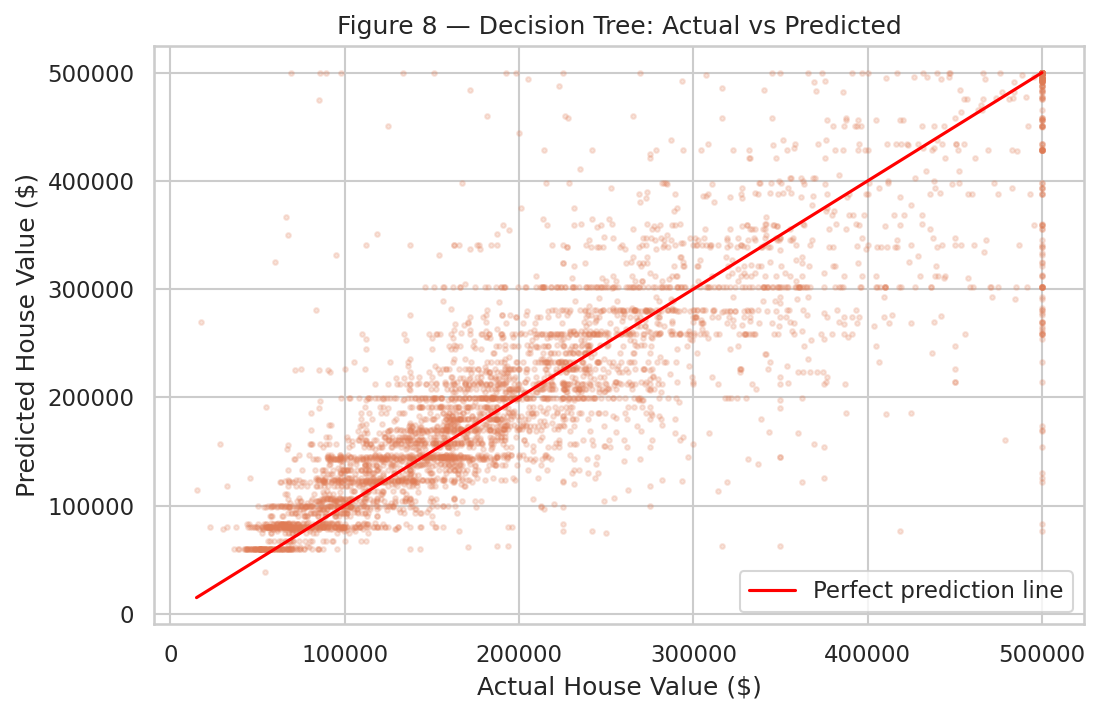

In [93]:
# CELL 21 — Decision Tree

# A Decision Tree makes predictions by asking yes/no questions
# about the features — like a flowchart.
# random_state=42 ensures the same result every time.

from sklearn.tree import DecisionTreeRegressor

# Step 1 — Create model
dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)

# Step 2 — Train the model
dt_model.fit(X_train, y_train)
print(" Decision Tree model trained!")

# Step 3 — Make predictions on the test set
dt_predictions = dt_model.predict(X_test)

# Step 4 — Measure performance
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_predictions))
dt_r2 = r2_score(y_test, dt_predictions)

print("\n Decision Tree Results ")
print(f"RMSE: ${dt_rmse:,.0f}")
print(f"R²:   {dt_r2:.3f}")

# Step 5 — Visualise predictions vs actual values
plt.figure(figsize=(8, 5))
plt.scatter(y_test, dt_predictions, alpha=0.2, s=5, color="#E07B54")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=1.5, label='Perfect prediction line')
plt.xlabel("Actual House Value ($)")
plt.ylabel("Predicted House Value ($)")
plt.title("Figure 8 — Decision Tree: Actual vs Predicted")
plt.legend()
plt.savefig("fig_dt_predictions.png")
plt.show()

In [27]:
# Random Forest


 Random Forest Results 
RMSE: $50,406
R²:   0.806


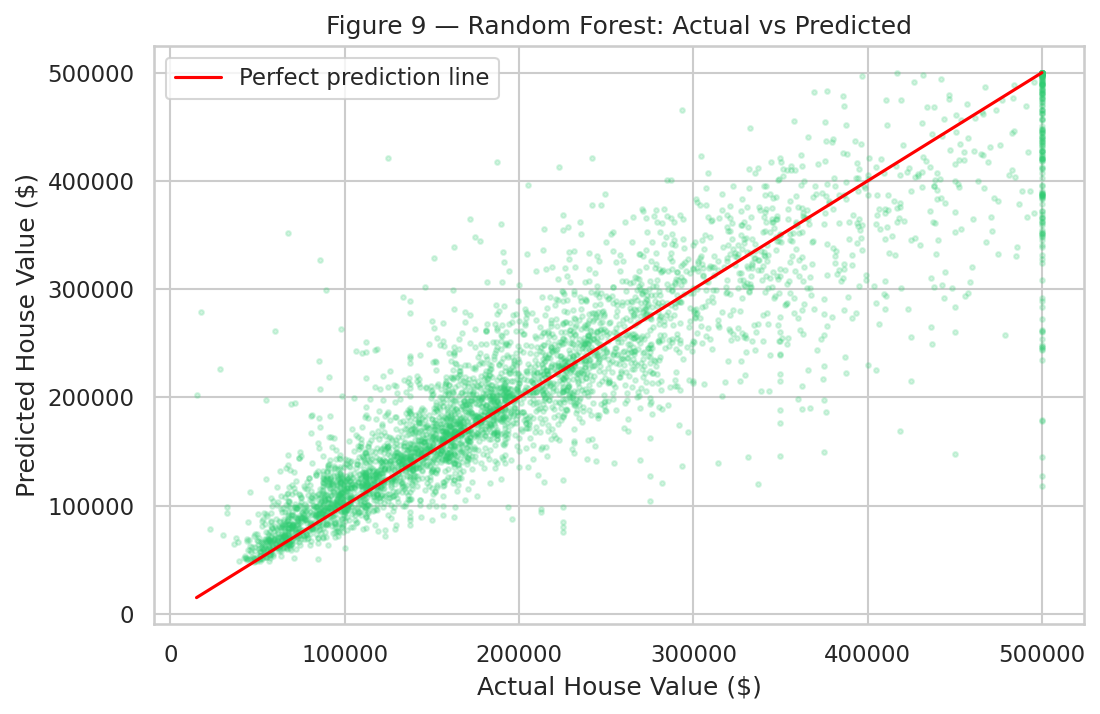

In [94]:
# CELL 22 — Random Forest

# Random Forest builds 100 decision trees, each trained on a slightly different random sample of the data.
# then averages all 100 predictions together.


from sklearn.ensemble import RandomForestRegressor

# Step 1 — Create model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Step 2 — Train model
rf_model.fit(X_train, y_train)

# Step 3 — Make predictions on the test set
rf_predictions = rf_model.predict(X_test)

# Step 4 — Measure performance
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("\n Random Forest Results " )
print(f"RMSE: ${rf_rmse:,.0f}")
print(f"R²:   {rf_r2:.3f}")

# Step 5 — Visualise predictions vs actual values
plt.figure(figsize=(8, 5))
plt.scatter(y_test, rf_predictions, alpha=0.2, s=5, color="#2ECC71")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=1.5, label='Perfect prediction line')
plt.xlabel("Actual House Value ($)")
plt.ylabel("Predicted House Value ($)")
plt.title("Figure 9 — Random Forest: Actual vs Predicted")
plt.legend()
plt.savefig("fig_rf_predictions.png")
plt.show()

In [96]:
# Model Comparison Chart and Visualisation

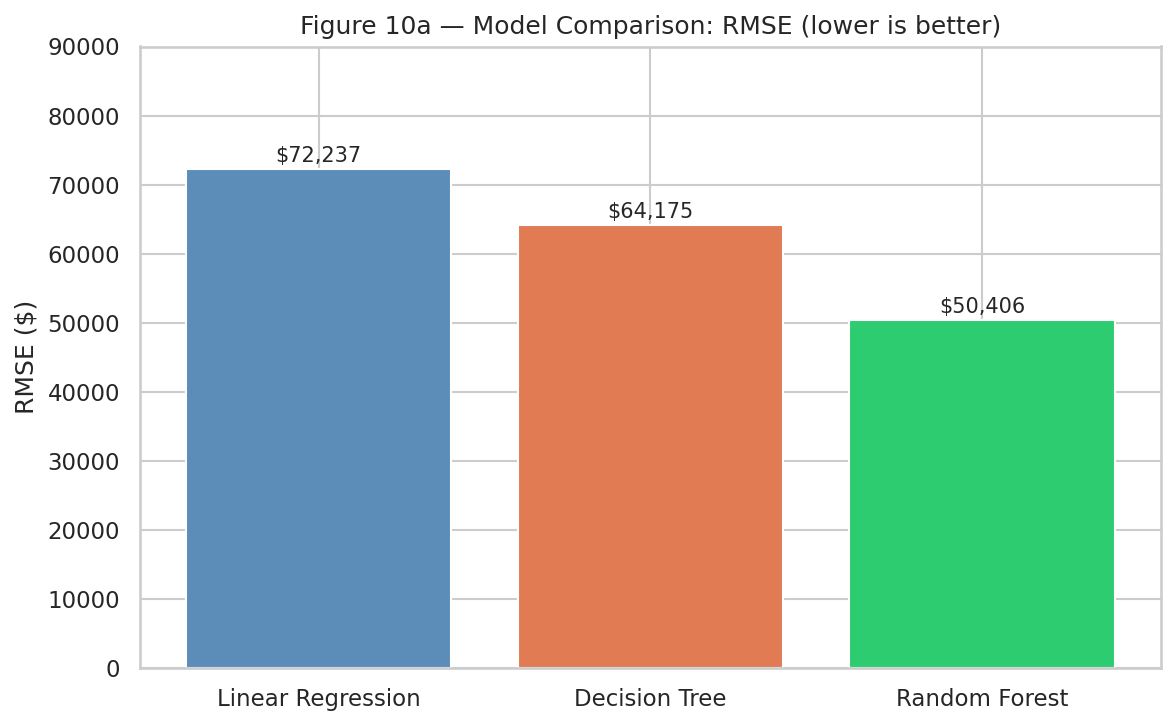

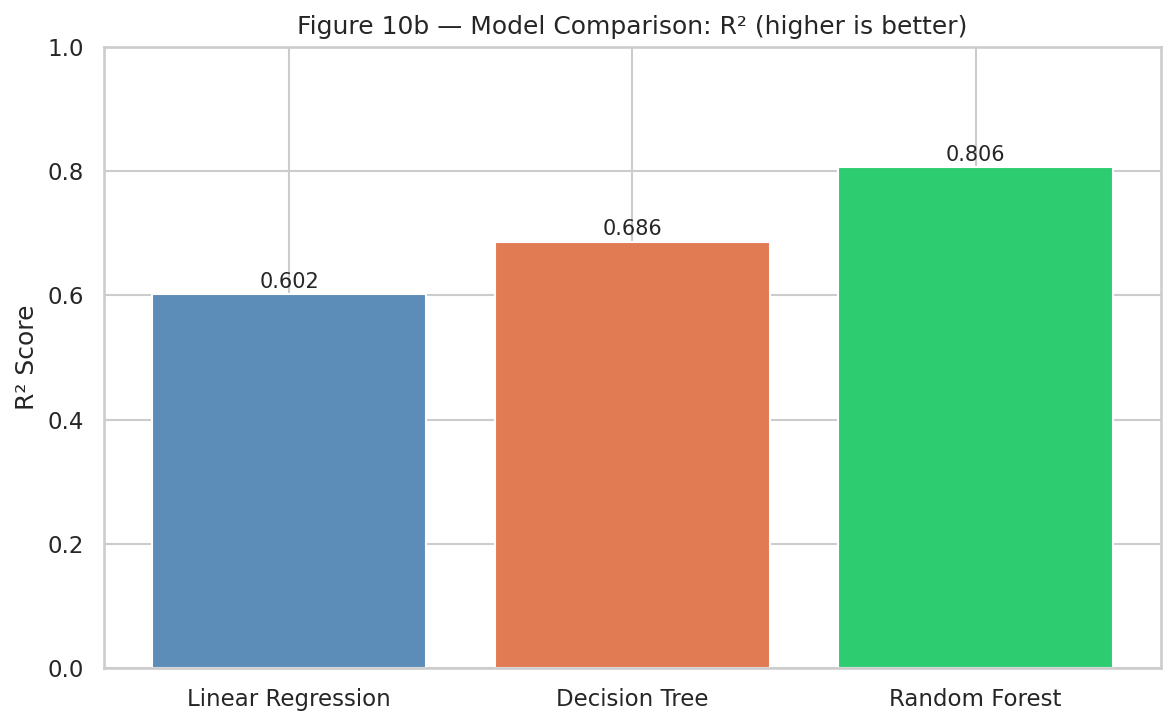

In [97]:
# CELL 23 — Model Comparison Chart

# Two charts:
#   Left  — RMSE comparison (lower bar = better model)
#   Right — R² comparison   (higher bar = better model)

models      = ['Linear Regression', 'Decision Tree', 'Random Forest']
rmse_scores = [72237, 64175, 50406]
r2_scores   = [0.602, 0.686, 0.806]

# Left chart: RMSE comparison
plt.figure(figsize=(8, 5))
bars = plt.bar(models, rmse_scores,
               color=["#5B8DB8", "#E07B54", "#2ECC71"],
               edgecolor="white")
plt.title("Figure 10a — Model Comparison: RMSE (lower is better)")
plt.ylabel("RMSE ($)")
plt.ylim(0, 90000)

# Add the value on top of each bar
for bar, value in zip(bars, rmse_scores):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 1000,
             f"${value:,}",
             ha='center', fontsize=10)

plt.tight_layout()
plt.savefig("fig_rmse_comparison.png")
plt.show()

#   Right chart: R² comparison
plt.figure(figsize=(8, 5))
bars = plt.bar(models, r2_scores,
               color=["#5B8DB8", "#E07B54", "#2ECC71"],
               edgecolor="white")
plt.title("Figure 10b — Model Comparison: R² (higher is better)")
plt.ylabel("R² Score")
plt.ylim(0, 1.0)

# Add the value on top of each bar
for bar, value in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.01,
             f"{value}",
             ha='center', fontsize=10)

plt.tight_layout()
plt.savefig("fig_r2_comparison.png")
plt.show()


In [98]:
# Feature Importance and visualisation

 Feature Importance Scores 
                   Feature  Importance
             median_income      0.4811
    ocean_proximity_INLAND      0.1375
  population_per_household      0.1210
                 longitude      0.0576
                  latitude      0.0561
        housing_median_age      0.0438
       rooms_per_household      0.0255
         bedrooms_per_room      0.0236
               total_rooms      0.0068
           log_total_rooms      0.0068
        log_total_bedrooms      0.0066
            total_bedrooms      0.0064
            log_population      0.0062
                population      0.0062
            log_households      0.0059
                households      0.0056
ocean_proximity_NEAR OCEAN      0.0024
  ocean_proximity_NEAR BAY      0.0009
    ocean_proximity_ISLAND      0.0001


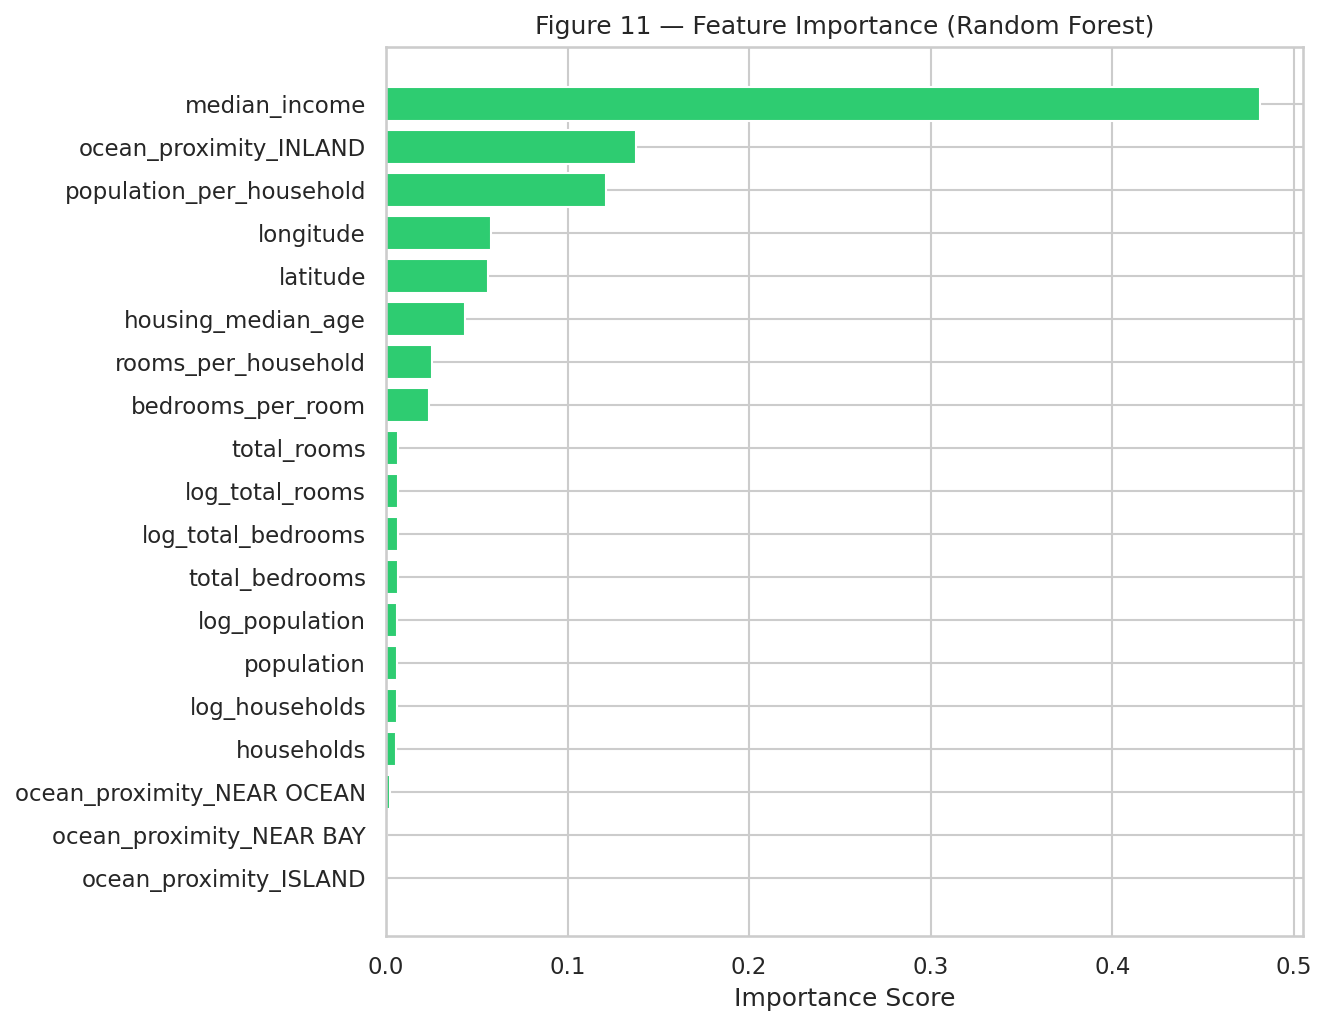

In [99]:
# CELL 24 — Feature Importance

# Most important model relied on to make accurate predictions.

# Get feature importance scores from the trained model
feature_names = X_train.columns.tolist()
importance_scores = rf_model.feature_importances_

# Put them into a DataFrame and sort highest to lowest
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_scores
})
importance_df = importance_df.sort_values('Importance', ascending=False)

# Print the scores
print(" Feature Importance Scores ")
print(importance_df.round(4).to_string(index=False))

# Plot as a horizontal bar chart
plt.figure(figsize=(9, 7))
plt.barh(importance_df['Feature'],
         importance_df['Importance'],
         color="#2ECC71", edgecolor="white")
plt.xlabel("Importance Score")
plt.title("Figure 11 — Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("fig_feature_importance.png")
plt.show()

In [33]:
# Residuals Plot

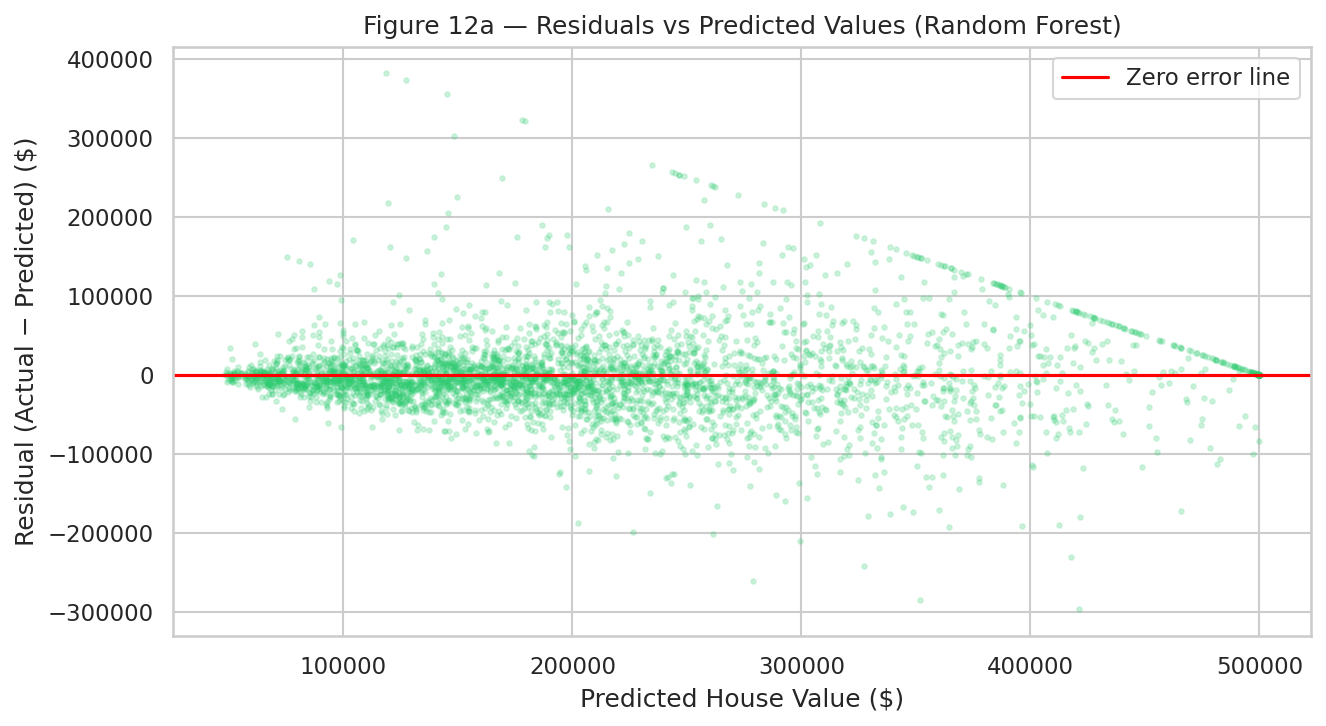

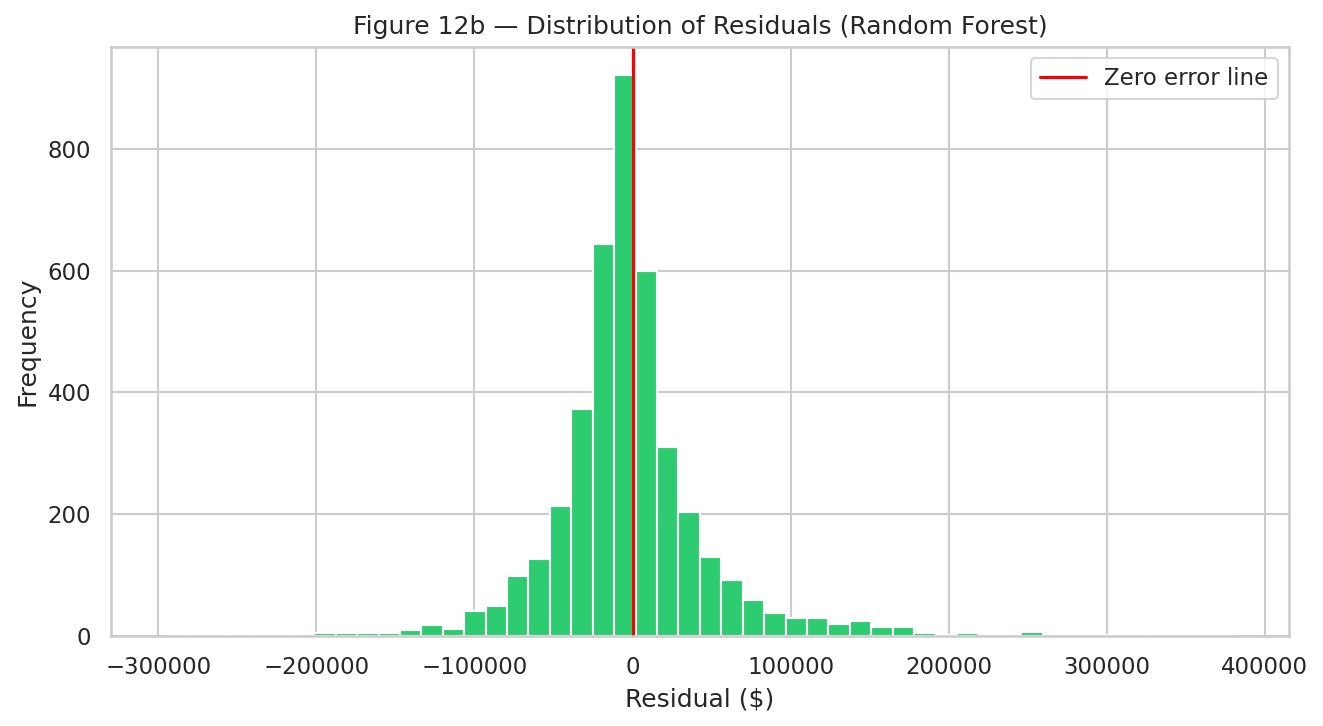

 Residual Summary 
Mean residual:   $-1,296
Std of residuals: $50,395
Max over-prediction:  $-296,235
Max under-prediction: $381,421


In [34]:
# CELL 25 — Residuals Plot

# Residuals = Actual price minus Predicted price
# A good model has residuals scattered randomly around zero.
# Patterns in residuals reveal where the model goes wrong.

# Calculate residuals
residuals = y_test - rf_predictions

#   Chart 1: Residuals vs Predicted Values
plt.figure(figsize=(9, 5))
plt.scatter(rf_predictions, residuals,
            alpha=0.2, s=5, color="#2ECC71")
plt.axhline(y=0, color='red', linewidth=1.5,
            label='Zero error line')
plt.xlabel("Predicted House Value ($)")
plt.ylabel("Residual (Actual − Predicted) ($)")
plt.title("Figure 12a — Residuals vs Predicted Values (Random Forest)")
plt.legend()
plt.tight_layout()
plt.savefig("fig_residuals.png")
plt.show()

#   Chart 2: Distribution of Residuals
plt.figure(figsize=(9, 5))
plt.hist(residuals, bins=50,
         color="#2ECC71", edgecolor="white")
plt.axvline(x=0, color='red', linewidth=1.5,
            label='Zero error line')
plt.xlabel("Residual ($)")
plt.ylabel("Frequency")
plt.title("Figure 12b — Distribution of Residuals (Random Forest)")
plt.legend()
plt.tight_layout()
plt.savefig("fig_residuals_dist.png")
plt.show()

# Print residual summary statistics
print(" Residual Summary ")
print(f"Mean residual:   ${residuals.mean():,.0f}")
print(f"Std of residuals: ${residuals.std():,.0f}")
print(f"Max over-prediction:  ${residuals.min():,.0f}")
print(f"Max under-prediction: ${residuals.max():,.0f}")